In [ ]:
'''LIBRARIES'''
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import joblib
import re
from sklearn.metrics import RocCurveDisplay

from wordcloud import WordCloud

from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from scipy.stats import loguniform
from scipy.sparse import csr_matrix

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.base import clone

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

from imblearn.over_sampling import SMOTE, RandomOverSampler
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler


from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.kernel_approximation import Nystroem
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import ComplementNB


from imblearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score,roc_auc_score
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix

In [2]:
data = pd.read_csv('/kaggle/input/competitions/comment-category-prediction-challenge/train.csv')
test_data = pd.read_csv('/kaggle/input/competitions/comment-category-prediction-challenge/test.csv')
sample_submission = pd.read_csv('/kaggle/input/competitions/comment-category-prediction-challenge/Sample.csv')

# EDA and Data preprocessing

In [3]:
print('------- Basic Information about data ------')
print(f"Shape: {data.shape}")
print(f"Columns: {data.columns.tolist()}")
print(f"Column types: {data.dtypes}")
print(data.head())

print('------- Basic information about test data -----')
print(f"Shape: {test_data.shape}")
print(f"Columns: {test_data.columns.tolist()}")
print(f"Column types: {test_data.dtypes}")
print(test_data.head())

print('------- Basic information about the sample submission :D -----')
print(f"Shape: {sample_submission.shape}")
print(f"Shape: {sample_submission.columns.tolist()}")
print(f"Column types: {sample_submission.dtypes}")
print(sample_submission.head())

------- Basic Information about data ------
Shape: (198000, 15)
Columns: ['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment', 'label']
Column types: created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race            object
religion        object
gender          object
disability        bool
comment         object
label            int64
dtype: object
                       created_date  post_id  emoticon_1  emoticon_2  \
0  2024-01-18 08:43:57.397508+00:00       73           0           0   
1  2024-03-24 21:43:11.490017+00:00       39           0           0   
2  2024-04-24 20:32:17.014931+00:00       31           0           1   
3  2023-05-28 22:00:14.214527+00:00       39           0           0   
4  2023-09-09 23:12:05

In [4]:
print(data.describe())

             post_id     emoticon_1     emoticon_2     emoticon_3  \
count  198000.000000  198000.000000  198000.000000  198000.000000   
mean       68.447429       0.279768       0.048338       0.121071   
std        27.948390       1.023234       0.258477       0.481013   
min        20.000000       0.000000       0.000000       0.000000   
25%        39.000000       0.000000       0.000000       0.000000   
50%        72.000000       0.000000       0.000000       0.000000   
75%        72.000000       0.000000       0.000000       0.000000   
max       129.000000      47.000000      11.000000      17.000000   

              upvote       downvote           if_1           if_2  \
count  198000.000000  198000.000000  198000.000000  198000.000000   
mean        2.607975       0.666394       1.906152       7.956212   
std         5.054763       2.044335      25.635752      14.839464   
min         0.000000       0.000000       0.000000       3.000000   
25%         0.000000       0.0000

In [5]:
for col in ['race', 'religion', 'gender']:
    non_null = data[col].notna().sum()
    pct = non_null / len(data) * 100
    print(f"{col}: {non_null} non-null ({pct:.1f}%)")

non_null_mask = data['race'].notna() 
non_null_df = data[non_null_mask]

print(f"Total non-null rows: {len(non_null_df)} ({len(non_null_df)/len(data)*100:.1f}%)")
print("\nClass distribution where race/religion/gender are non-null:")
print(non_null_df['label'].value_counts().sort_index())
print("\nAs percentage:")
print(non_null_df['label'].value_counts(normalize=True).sort_index().mul(100).round(1))

for col in ['race', 'religion', 'gender']:
    non_null_df = data[data[col].notna()]
    print(f"\n{col} — class distribution when non-null:")
    print(non_null_df['label'].value_counts(normalize=True).mul(100).round(1))

race: 52577 non-null (26.6%)
religion: 52577 non-null (26.6%)
gender: 52577 non-null (26.6%)
Total non-null rows: 52577 (26.6%)

Class distribution where race/religion/gender are non-null:
label
0    23657
1    13208
2    14594
3     1118
Name: count, dtype: int64

As percentage:
label
0    45.0
1    25.1
2    27.8
3     2.1
Name: proportion, dtype: float64

race — class distribution when non-null:
label
0    45.0
2    27.8
1    25.1
3     2.1
Name: proportion, dtype: float64

religion — class distribution when non-null:
label
0    45.0
2    27.8
1    25.1
3     2.1
Name: proportion, dtype: float64

gender — class distribution when non-null:
label
0    45.0
2    27.8
1    25.1
3     2.1
Name: proportion, dtype: float64


In [6]:
print(data['if_1'].value_counts())
print(data['if_2'].value_counts())

print(pd.crosstab(data['if_1'], data['label'], normalize='index').mul(100).round(1))
print(pd.crosstab(data['if_2'], data['label'], normalize='index').mul(100).round(1))

train_posts = set(data['post_id'].unique())
test_posts = set(test_data['post_id'].unique())
overlap = train_posts & test_posts
print(f"Shared post_ids: {len(overlap)}")
print(f"Train only: {len(train_posts - test_posts)}")
print(f"Test only: {len(test_posts - train_posts)}")

if_1
0       145423
4        31061
10       11849
6         6774
5         2691
7           70
9           45
11          32
12           2
1814         2
1545         2
1783         2
8            2
1551         2
249          1
1569         1
1800         1
1560         1
1263         1
1267         1
1258         1
1543         1
250          1
1815         1
1538         1
1585         1
1830         1
1277         1
1807         1
1810         1
1777         1
1848         1
1257         1
1548         1
1232         1
1583         1
1572         1
1576         1
1256         1
1566         1
1547         1
1825         1
1271         1
1838         1
1553         1
1846         1
1558         1
1557         1
1767         1
1819         1
1581         1
1254         1
1811         1
1860         1
1778         1
1827         1
1584         1
Name: count, dtype: int64
if_2
4       91726
10      80693
6       14558
5        6188
70        453
        ...  
1694        1
1527       

In [7]:
print(data['emoticon_1'].value_counts())
print(data['emoticon_2'].value_counts())
print(data['emoticon_3'].value_counts())

print(pd.crosstab(data['emoticon_1'], data['label'], normalize='index').mul(100).round(1))
print(pd.crosstab(data['emoticon_2'], data['label'], normalize='index').mul(100).round(1))
print(pd.crosstab(data['emoticon_3'], data['label'], normalize='index').mul(100).round(1))


emoticon_1
0     169078
1      17683
2       5799
3       2362
4       1243
5        638
6        374
7        225
8        162
9        102
10        69
11        68
12        40
13        27
15        20
16        20
14        19
19        13
17         9
23         7
22         6
20         5
18         5
36         4
25         4
27         3
24         2
21         2
31         2
30         2
32         2
28         1
46         1
33         1
47         1
39         1
Name: count, dtype: int64
emoticon_2
0     189891
1       7031
2        822
3        177
4         48
5         21
6          7
8          1
11         1
7          1
Name: count, dtype: int64
emoticon_3
0     180835
1      13017
2       2777
3        764
4        309
5        132
6         79
7         41
8         14
10        12
9          9
11         4
14         2
13         2
12         2
17         1
Name: count, dtype: int64
label           0      1      2     3
emoticon_1                           
0      

In [8]:
data['emoticon_2_present'] = (data['emoticon_2'] > 0).astype(int)
data['emoticon_3_present'] = (data['emoticon_3'] > 0).astype(int)

test_data['emoticon_2_present'] = (test_data['emoticon_2'] > 0).astype(int)
test_data['emoticon_3_present'] = (test_data['emoticon_3'] > 0).astype(int)

#data['emoticon_sum'] = data['emoticon_1']+data['emoticon_2']+data['emoticon_3']
#print(pd.crosstab(data['emoticon_sum'], data['label'], normalize='index').mul(100).round(1))


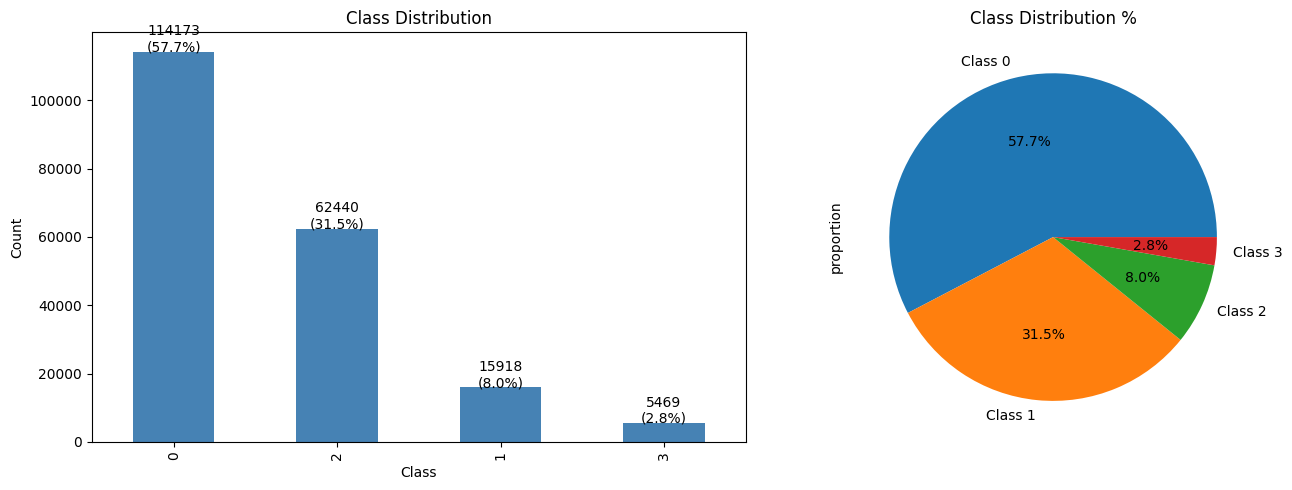

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data['label'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(data['label'].value_counts()):
    axes[0].text(i, v + 100, f'{v}\n({v/len(data)*100:.1f}%)', ha='center')

data['label'].value_counts(normalize=True).mul(100).plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    labels=['Class 0', 'Class 1', 'Class 2', 'Class 3']
)
axes[1].set_title('Class Distribution %')
plt.tight_layout()
plt.show()


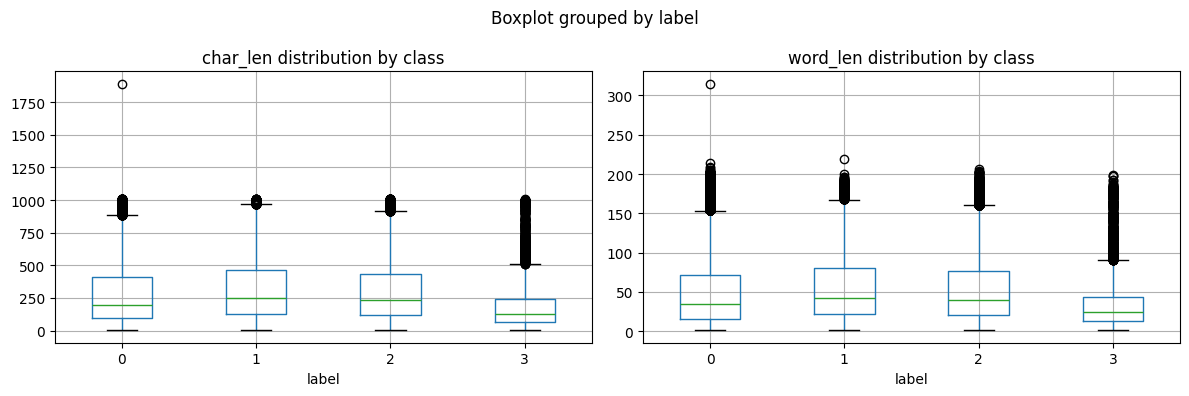

In [10]:
data['char_len'] = data['comment'].str.len()
data['word_len'] = data['comment'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['char_len', 'word_len']):
    data.boxplot(column=col, by='label', ax=ax)
    ax.set_title(f'{col} distribution by class')
plt.tight_layout()

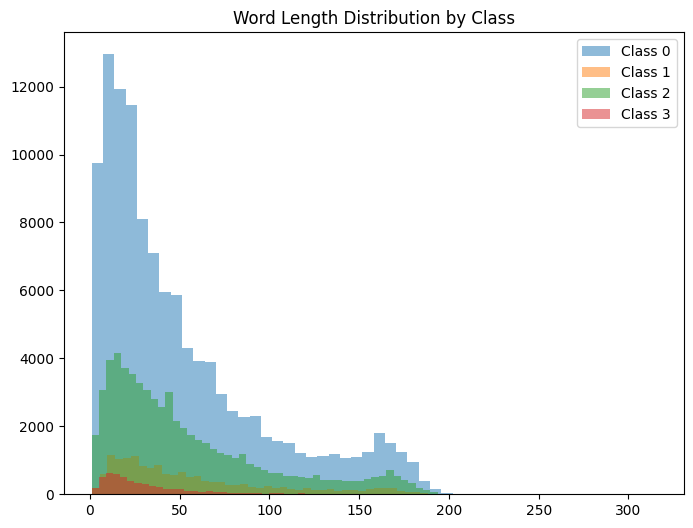

In [11]:
plt.figure(figsize=(8,6))

for label in range(4):
    subset = data[data['label'] == label]['word_len']
    plt.hist(subset, bins=50, alpha=0.5, label=f'Class {label}')
plt.title('Word Length Distribution by Class')
plt.legend()

<Figure size 800x600 with 0 Axes>

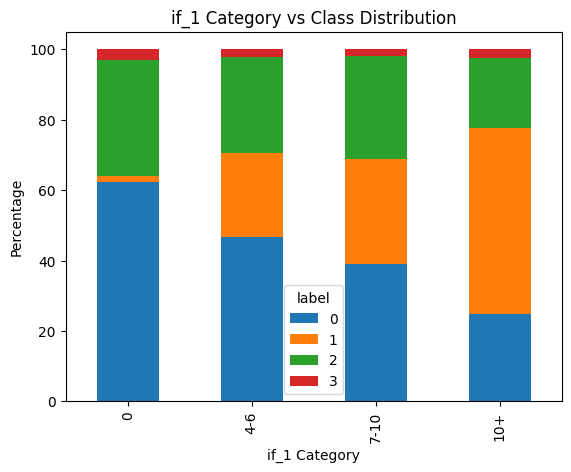

In [12]:
plt.figure(figsize=(8,6))

pd.crosstab(
    pd.cut(data['if_1'], bins=[-1,0,3,6,10,float('inf')],
           labels=['0','1-3','4-6','7-10','10+']),
    data['label'],
    normalize='index'
).mul(100).plot(kind='bar', stacked=True)

plt.title('if_1 Category vs Class Distribution')
plt.xlabel('if_1 Category')
plt.ylabel('Percentage')

plt.show()

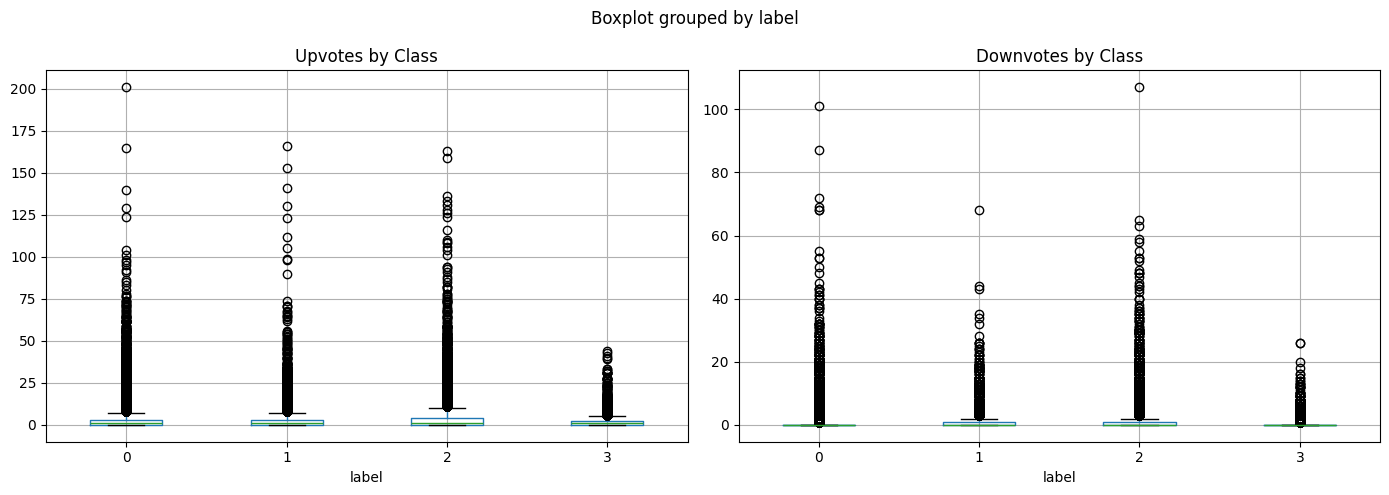

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
data.boxplot(column='upvote', by='label', ax=axes[0])
axes[0].set_title('Upvotes by Class')
data.boxplot(column='downvote', by='label', ax=axes[1])
axes[1].set_title('Downvotes by Class')
plt.tight_layout()
plt.show()


In [14]:
data['disability'] =data['disability'].astype(int)
test_data['disability'] = test_data['disability'].astype(int)

In [15]:
data['created_date'] = pd.to_datetime(data['created_date'])
test_data['created_date'] = pd.to_datetime(test_data['created_date'])

print(data['created_date'].dtype)
print(test_data['created_date'].dtype)

data['year'] = data['created_date'].dt.year
data['month'] = data['created_date'].dt.month
data['day'] = data['created_date'].dt.day
data['hour'] = data['created_date'].dt.hour

test_data['year'] = test_data['created_date'].dt.year
test_data['month'] = test_data['created_date'].dt.month
test_data['day'] = test_data['created_date'].dt.day
test_data['hour'] = test_data['created_date'].dt.hour

data.drop('created_date', axis = 1, inplace = True)
test_data.drop('created_date', axis = 1, inplace = True)

datetime64[ns, UTC]
datetime64[ns, UTC]


In [16]:
'''data['if1_is_high'] = (data['if_1'] > 100).astype(int)
data['if1_category'] = pd.cut(data['if_1'], 
                             bins=[-1, 0, 3, 6, 10, float('inf')], 
                             labels=['zero', 'low', 'mid', 'high', 'very_high'])

test_data['if1_is_high'] = (test_data['if_1'] > 100).astype(int)
test_data['if1_category'] = pd.cut(test_data['if_1'],
                                    bins=[-1, 0, 3, 6, 10, float('inf')],
                                    labels=['zero', 'low', 'mid', 'high', 'very_high'])'''

"data['if1_is_high'] = (data['if_1'] > 100).astype(int)\ndata['if1_category'] = pd.cut(data['if_1'], \n                             bins=[-1, 0, 3, 6, 10, float('inf')], \n                             labels=['zero', 'low', 'mid', 'high', 'very_high'])\n\ntest_data['if1_is_high'] = (test_data['if_1'] > 100).astype(int)\ntest_data['if1_category'] = pd.cut(test_data['if_1'],\n                                    bins=[-1, 0, 3, 6, 10, float('inf')],\n                                    labels=['zero', 'low', 'mid', 'high', 'very_high'])"

In [17]:
print("Year dtype:", data['year'].dtype)
print("Month dtype:", data['month'].dtype)
print("Hour dtype:", data['hour'].dtype)

Year dtype: int32
Month dtype: int32
Hour dtype: int32


In [18]:
for col in data.columns:
    if data[col].dtype == 'int64' or data[col].dtype=='int32':
        print(f"{col} : min = {data[col].min()}, max = {data[col].max()}")

post_id : min = 20, max = 129
emoticon_1 : min = 0, max = 47
emoticon_2 : min = 0, max = 11
emoticon_3 : min = 0, max = 17
upvote : min = 0, max = 201
downvote : min = 0, max = 107
if_1 : min = 0, max = 1860
if_2 : min = 3, max = 1833
disability : min = 0, max = 1
label : min = 0, max = 3
emoticon_2_present : min = 0, max = 1
emoticon_3_present : min = 0, max = 1
year : min = 2022, max = 2024
month : min = 1, max = 12
day : min = 1, max = 31
hour : min = 0, max = 23


In [19]:
int_df = data.select_dtypes(include=['int64', 'int32'])
overall_min = int_df.min().min()
overall_max = int_df.max().max()

print("Min:", overall_min)
print("Max:", overall_max)

Min: 0
Max: 2024


In [20]:
print("Number of unique values per column")
for col in data.columns:
    print(f'{col} - {data[col].nunique()}')
    
print("\nNumber of null values per column")
for col in data.columns:
    print(f'{col} - {data[col].isnull().sum()}')       

Number of unique values per column
post_id - 52
emoticon_1 - 36
emoticon_2 - 10
emoticon_3 - 16
upvote - 122
downvote - 62
if_1 - 57
if_2 - 81
race - 6
religion - 8
gender - 5
disability - 2
comment - 197842
label - 4
emoticon_2_present - 2
emoticon_3_present - 2
char_len - 1007
word_len - 211
year - 3
month - 12
day - 31
hour - 24

Number of null values per column
post_id - 0
emoticon_1 - 0
emoticon_2 - 0
emoticon_3 - 0
upvote - 0
downvote - 0
if_1 - 0
if_2 - 0
race - 145423
religion - 145423
gender - 145423
disability - 0
comment - 1
label - 0
emoticon_2_present - 0
emoticon_3_present - 0
char_len - 1
word_len - 1
year - 0
month - 0
day - 0
hour - 0


In [21]:
data.fillna({'comment':"", 'race':'unknown', 'gender':'unknown', 'religion':'unknown'}, 
            inplace = True)

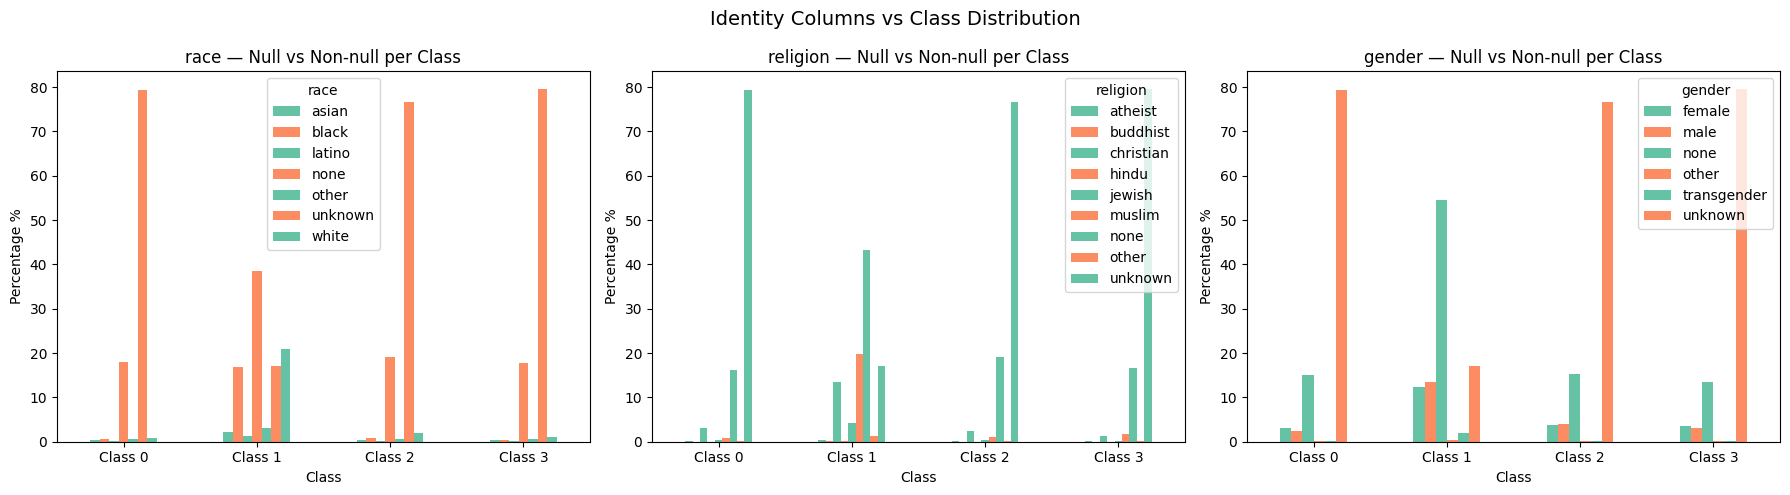

In [22]:
colors = sns.color_palette("Set2", 2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Identity Columns vs Class Distribution', fontsize=14)

for ax, col in zip(axes, ['race', 'religion', 'gender']):
    temp = data.copy()
    ct = pd.crosstab(temp['label'], temp[col], normalize='index').mul(100)
    ct.plot(kind='bar', ax=ax, color=colors)
    ax.set_title(f'{col} — Null vs Non-null per Class')
    ax.set_xlabel('Class')
    ax.set_ylabel('Percentage %')
    ax.set_xticklabels([f'Class {i}' for i in range(4)], rotation=0)
    ax.legend(title=col)

plt.tight_layout()
plt.show()

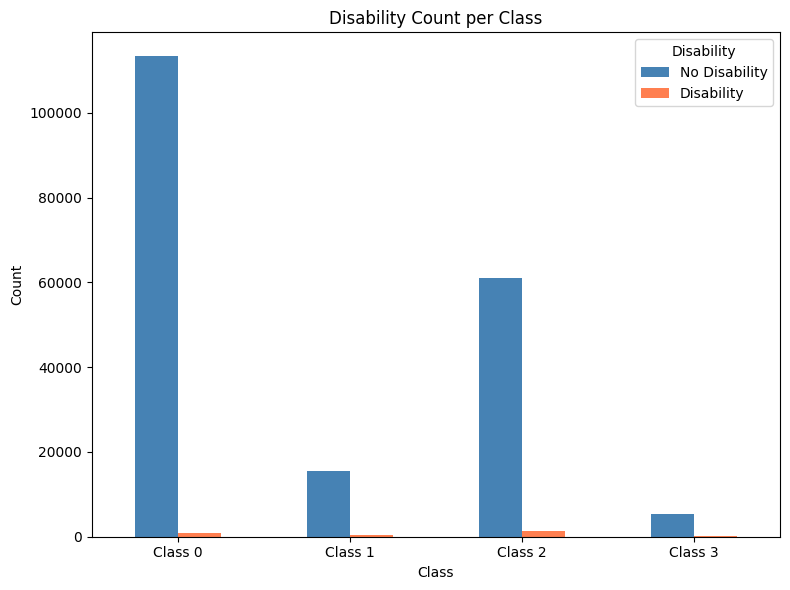

Disability rate per class:
disability      0     1
label                  
0           99.25  0.75
1           97.34  2.66
2           97.76  2.24
3           98.90  1.10


In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

disability_counts = data.groupby(['label', 'disability']).size().unstack(fill_value=0)
disability_counts.columns = ['No Disability', 'Disability']
disability_counts.plot(kind='bar', color=['steelblue', 'coral'], ax=ax)

plt.title('Disability Count per Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.legend(title='Disability')
plt.xticks([0,1,2,3], [f'Class {i}' for i in range(4)], rotation=0)

plt.tight_layout()
plt.show()

print("Disability rate per class:")
print(pd.crosstab(data['label'], data['disability'],
                  normalize='index').mul(100).round(2))

In [24]:
pd.set_option('display.max_colwidth', None)

for i in range(4):
    print(f'LABEL - {i}')
    display(data.loc[data.label == i]['comment'])
    print('\n')


LABEL - 0


1                                                                                                                                                                                                                                                                                                                                                                       Under Alaska law, a non-tribal member is not bound to tribal court.. Living in a particular community does not change your rights under state and federal law. In this case, Connor can basically flip the bird to the tribal court and there's nothing they can actually do. The only courts it appears he is subject to are those formally established under state and federal law, which does not recognize this.\n\nThe tribal court can at-best basically use it's influence to get tribal members and others in the community to refuse to associate with Connor and not do business with him, essentially acting like a shunning until Connor decides to 



LABEL - 1


10                                                                                                                                                                                                                                                                                                                                                                                                                            You're right the words Muslim ban came straight from trump.
35                                                                                                                                                                                                                   Why do I get the suspicion that this is a liberal posting what they think anyone who supports our constitutionally guaranteed second amendment rights would say? Kind of like the girl who wrote foul words on her face and then blamed it on racist white guys? bby
41                                                  



LABEL - 2


0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              She might be a bright spot for a party keou on Oahu dominated by greedy criminals or ethically challenged individuals.
2 



LABEL - 3


40                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           Now that I poisoned the pond, I am not going to swim anym ore.
45        This is a city tra

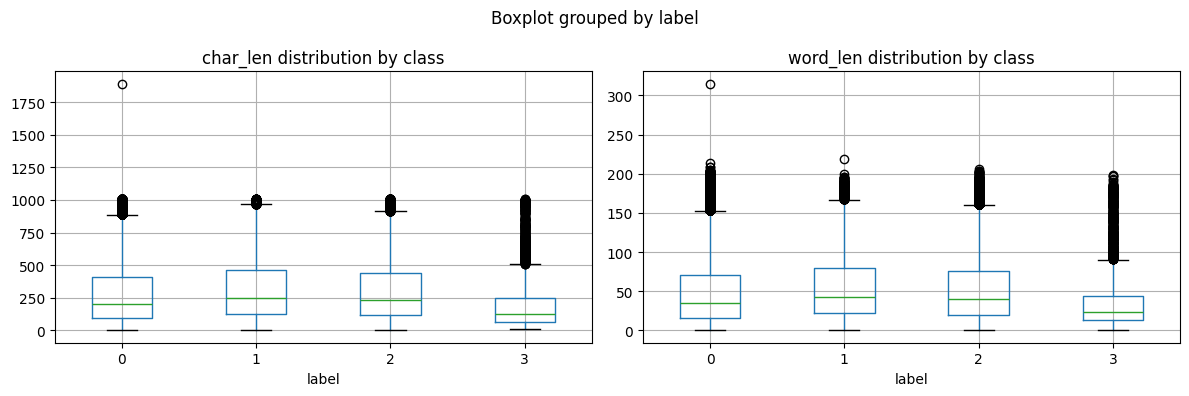

In [25]:
data['char_len'] = data['comment'].str.len()
data['word_len'] = data['comment'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['char_len', 'word_len']):
    data.boxplot(column=col, by='label', ax=ax)
    ax.set_title(f'{col} distribution by class')
plt.tight_layout()

In [26]:
print('Percentage of each class in data: ')
percentages = data['label'].value_counts(normalize=True).sort_index() * 100
print(percentages)

Percentage of each class in data: 
label
0    57.663131
1     8.039394
2    31.535354
3     2.762121
Name: proportion, dtype: float64


In [27]:
for col in data.columns:
    print(f"---- {col} ---")
    print(data.groupby('label')[col].describe())
    print('\n')

---- post_id ---
          count       mean        std   min   25%   50%   75%    max
label                                                               
0      114173.0  67.764857  27.485908  24.0  39.0  72.0  72.0  129.0
1       15918.0  70.657369  26.918877  24.0  40.0  72.0  72.0  123.0
2       62440.0  69.149103  28.766447  20.0  39.0  72.0  73.0  129.0
3        5469.0  68.253794  30.362452  24.0  39.0  72.0  73.0  123.0


---- emoticon_1 ---
          count      mean       std  min  25%  50%  75%   max
label                                                        
0      114173.0  0.283561  1.072695  0.0  0.0  0.0  0.0  47.0
1       15918.0  0.264669  0.967069  0.0  0.0  0.0  0.0  39.0
2       62440.0  0.276890  0.943357  0.0  0.0  0.0  0.0  33.0
3        5469.0  0.277382  1.000568  0.0  0.0  0.0  0.0  23.0


---- emoticon_2 ---
          count      mean       std  min  25%  50%  75%   max
label                                                        
0      114173.0  0.043101  0.

In [28]:
X = data.drop('label', axis = 1)
y = data['label']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2,
                                                  stratify = y, random_state = 42)

X_test = test_data.copy()

In [29]:
print('=== Basic info about train and val sets ===')
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")

train_counts = y_train.value_counts().sort_index().to_numpy()
val_counts = y_val.value_counts().sort_index().to_numpy()

print("\nClass distributions in train and val sets")
print(train_counts)
print(val_counts)

print("\nClass percentages in train and val sets")
train_percent = y_train.value_counts(normalize=True).sort_index().to_numpy()
val_percent = y_val.value_counts(normalize=True).sort_index().to_numpy()

print(train_percent)
print(val_percent)

=== Basic info about train and val sets ===
X_train shape: (158400, 21)
X_val shape: (39600, 21)
y_train shape: (158400,)
y_val shape: (39600,)

Class distributions in train and val sets
[91338 12735 49952  4375]
[22835  3183 12488  1094]

Class percentages in train and val sets
[0.57662879 0.08039773 0.31535354 0.02761995]
[0.57664141 0.08037879 0.31535354 0.02762626]


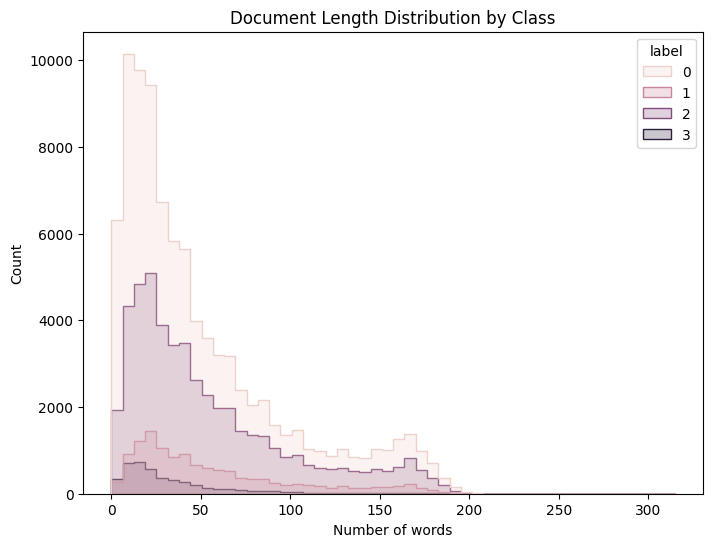

In [30]:
lengths = X_train['comment'].str.split().apply(len)

plt.figure(figsize=(8,6))
sns.histplot(data=X_train, x=lengths, hue=y_train, bins=50, element="step")
plt.title("Document Length Distribution by Class")
plt.xlabel("Number of words")
plt.show()

In [31]:
def get_distinctive_ngrams(texts,labels,target_label,n=20,min_df=3,min_count=5,
    ngram_range=(1,2),smoothing=1.0):

    vec = CountVectorizer(lowercase=True,stop_words='english',
        ngram_range=ngram_range,min_df=min_df)

    X = vec.fit_transform(texts)
    y = np.array(labels)

    target_mask = (y == target_label)
    other_mask = ~target_mask

    target_sum = X[target_mask].sum(axis=0).A1
    other_sum = X[other_mask].sum(axis=0).A1

    target_norm = target_sum / max(target_mask.sum(), 1)
    other_norm = other_sum / max(other_mask.sum(), 1)

    ratio = np.log((target_norm + smoothing) / (other_norm + smoothing))

    feature_names = vec.get_feature_names_out()
    valid_idx = np.where(target_sum >= min_count)[0]
    sorted_idx = valid_idx[np.argsort(ratio[valid_idx])][::-1]

    top_idx = sorted_idx[:n]

    results = [(feature_names[i], ratio[i], target_norm[i])for i in top_idx]

    return results, vec

In [32]:
indicator_words = set()
class_wordsets = {}
class_word_scores = {}

for label in sorted(set(y_train)):
    top_words, _ = get_distinctive_ngrams(
        texts=X_train['comment'],
        labels=y_train,
        target_label=label,
        n=15
    )

    print(f"\nClass {label} distinctive n-grams:")
    class_wordsets[label] = set()
    class_word_scores[label] = {}

    for gram, score, freq in top_words:
        print(f"{gram:20s} | score={score:.2f} | freq={freq:.4f}")
        indicator_words.add(gram)
        class_wordsets[label].add(gram)
        class_word_scores[label][gram] = score


Class 0 distinctive n-grams:
tax                  | score=0.02 | freq=0.0575
state                | score=0.02 | freq=0.0620
year                 | score=0.01 | freq=0.0436
pay                  | score=0.01 | freq=0.0436
income               | score=0.01 | freq=0.0212
years                | score=0.01 | freq=0.0698
oil                  | score=0.01 | freq=0.0294
work                 | score=0.01 | freq=0.0450
cost                 | score=0.01 | freq=0.0222
new                  | score=0.01 | freq=0.0456
money                | score=0.01 | freq=0.0583
taxes                | score=0.01 | freq=0.0260
000                  | score=0.01 | freq=0.0228
alaska               | score=0.01 | freq=0.0280
market               | score=0.01 | freq=0.0156

Class 1 distinctive n-grams:
white                | score=0.32 | freq=0.4119
black                | score=0.21 | freq=0.2409
muslims              | score=0.14 | freq=0.1506
muslim               | score=0.13 | freq=0.1418
people               | score

In [33]:
indicator_wordset = set(indicator_words)

default_stopwords = set(ENGLISH_STOP_WORDS)
custom_stopwords = list(default_stopwords - indicator_wordset)

In [34]:
X_train['comment'] = X_train['comment'].str.lower()
X_val['comment'] = X_val['comment'].str.lower()
X_test['comment'] = X_test['comment'].str.lower()

In [35]:
def weighted_indicator_features(text, class_word_scores):
    words = text.lower().split()
    features = {}
    
    for label, word_scores in class_word_scores.items():
        score = sum(word_scores.get(w, 0) for w in words)
        features[f'class_{label}_score'] = score
    
    return features

In [36]:
X_train_extra = X_train['comment'].apply(
    lambda x: weighted_indicator_features(x, class_word_scores)).apply(pd.Series)

X_val_extra = X_val['comment'].apply(
    lambda x: weighted_indicator_features(x, class_word_scores)).apply(pd.Series)

X_test_extra = X_test['comment'].apply(
    lambda x: weighted_indicator_features(x, class_word_scores)).apply(pd.Series)

In [37]:
word_tfidf = TfidfVectorizer(max_features=50000,min_df=3,max_df=0.85,
    ngram_range=(1,3),stop_words = custom_stopwords,sublinear_tf = True)

char_tfidf = TfidfVectorizer(analyzer='char',max_features=30000, min_df=3,
    max_df=0.95,ngram_range=(3,6),sublinear_tf=True)


In [38]:
X_train_word = word_tfidf.fit_transform(X_train['comment'])
X_train_char = char_tfidf.fit_transform(X_train['comment'])

X_val_word = word_tfidf.transform(X_val['comment'])
X_val_char = char_tfidf.transform(X_val['comment'])

X_test_word = word_tfidf.transform(X_test['comment'])
X_test_char = char_tfidf.transform(X_test['comment'])

In [39]:
cat_cols = ['emoticon_1', 'emoticon_2', 'emoticon_3', 'if_2','disability',
           'emoticon_2_present', 'emoticon_3_present','if_1']
num_cols = ['upvote', 'downvote', 'year','month', 'day', 'hour']
enc_cols = ['race', 'religion', 'gender']


preprocessor = ColumnTransformer(
    transformers=[
        ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=True), enc_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols),
        ('num', MinMaxScaler(), num_cols),
    ]
)

In [40]:
X_train_struct = preprocessor.fit_transform(X_train)
X_val_struct = preprocessor.transform(X_val)
X_test_struct = preprocessor.transform(X_test)

In [41]:
from scipy.sparse import hstack

X_train_final = hstack([X_train_word, X_train_char, X_train_extra, X_train_struct])
X_val_final = hstack([X_val_word, X_val_char, X_val_extra, X_val_struct])
X_test_final = hstack([X_test_word, X_test_char, X_test_extra, X_test_struct])

X_train_final = X_train_final.astype(np.float32)
X_val_final   = X_val_final.astype(np.float32)
X_test_final  = X_test_final.astype(np.float32)

# Model Pipeline

In [42]:
'''param_dict = {
    # ----- TF-IDF -----
    "prep__text__tfidf__max_features": [4000, 5000, 6000],
    "prep__text__tfidf__ngram_range": [(1, 2), (1, 3), (1, 4)],
    "prep__text__tfidf__min_df": [2, 5],

    # ----- SVD -----
    "prep__text__svd__n_components": [50, 100, 200],

    # ---- XGB  ----
    "model__n_estimators": [300, 500, 700],
    "model__learning_rate": [0.005, 0.01, 0.02],
    "model__max_depth": [4, 5, 6],

    "model__subsample": [0.85, 0.9, 0.95],
    "model__colsample_bytree": [0.9, 1.0],

    "model__gamma": [0.03, 0.05, 0.1],
    "model__reg_lambda": [3, 5, 7],
    "model__reg_alpha": [0.5, 1, 2],
}



param_dict = {
    # ----- TF-IDF tuning  -----
    "prep__text__max_features": [5000, 10000, 20000],
    "prep__text__ngram_range": [(1,1), (1,2)],
    "prep__text__min_df": [2, 5, 10],

    # ----- RandomForest tuning -----
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 20, 40],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],

     # ----- Logistic Regression -----
    "model__C": [0.001, 0.01, 0.1, 1],
    "model__solver": ["saga"],
    "model__penalty": ["l2"],  # safe with both solvers
    "model__class_weight": [None, "balanced"],
    "model__max_iter": [500, 1000, 2000]

     # ----- XGBoost -----
    "model__n_estimators": [100, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__subsample": [0.7, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.9, 1.0],
    "model__gamma": [0, 0.1, 0.3],
    "model__reg_lambda": [1, 5, 10],   # L2 regularization
    "model__reg_alpha": [0, 0.1, 1]    # L1 regularization

    # ---------- Light gbm tuning ----------
    "model__n_estimators": [200, 500],
    "model__learning_rate": [0.01, 0.1],
    "model__max_depth": [-1, 10],
    "model__num_leaves": [31, 63],
    "model__min_child_samples": [10, 20],
    "model__reg_alpha": [0, 0.1],
    "model__reg_lambda": [0, 0.1],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__subsample": [0.7, 1.0],
    "model__min_gain_to_split": [0.0, 0.1]
}

'''

#param_dict = {
    # Word TF-IDF
    #"prep__tfidf__word__max_features": [25000, 40000,50000],
    #"prep__tfidf__word__min_df": [2, 3, 4],
    #"prep__tfidf__word__max_df": [0.85, 0.9, 0.95],
    #"prep__tfidf__word__ngram_range": [(1,2), (1,3)],

    # Char TF-IDF
    #"prep__tfidf__char__max_features": [20000, 30000],
    #"prep__tfidf__char__min_df": [1, 2, 3],
    #"prep__tfidf__char__max_df": [0.85, 0.9, 0.95],
    #"prep__tfidf__char__ngram_range": [(3,5), (2,4)],

    #LR
    #"model__C": [0.05, 1, 2],
    #"model__solver": ['lbfgs', 'saga'],
    #"model__penalty": ["l2", 'l2'],  
    #"model__class_weight": [None],
    #"model__max_iter": [10000]

    #RF
    #"model__n_estimators": [200, 500, 700],
    #"model__max_depth": [None, 20, 60],
    #"model__min_samples_split": [2, 5, 10],
    #"model__min_samples_leaf": [1, 2, 4]

    #LinearSVC
    #"model__C": loguniform(0.05, 1),
    #"model__loss": ["hinge", "squared_hinge"],
    #"model__penalty": ["l2"],
    #"model__class_weight": [
    #    "balanced",
    #    {0:1, 1:3, 2:1.5, 3:6},
    #    {0:1, 1:4, 2:1.5, 3:8}
    #],
    #"model__max_iter": [8000, 10000]

    #SDGClassifier
    #"model__loss": ["hinge", "squared_hinge"],        
    #"model__penalty": ["l2", "elasticnet"],          
    #"model__alpha": loguniform(1e-5, 1e-2),         
    #"model__class_weight": [
    #    "balanced", 
    #    {0:1, 1:4, 2:1.5, 3:8}, 
    #    {0:1, 1:3, 2:1.5, 3:6}
    #],
    #"model__max_iter": [5000, 8000, 10000],          
    #"model__learning_rate": ["optimal", "adaptive"],
    #"model__eta0": [0.01, 0.1, 0.5]     

    #XGB
    #"model__n_estimators": [300, 500],
    #"model__learning_rate": [0.01, 0.1],
    #"model__max_depth": [3, 5],
    #"model__subsample": [0.7, 0.9],
    #"model__colsample_bytree": [0.7, 0.9],
    #"model__gamma": [0, 0.1],
    #"model__reg_lambda": [1, 5, 10],   
    #"model__reg_alpha": [0, 0.1, 1]    

    #LGBM
    #"model__n_estimators": [200, 500],
    #"model__learning_rate": [0.01, 0.1],
    #"model__max_depth": [-1, 10],
    #"model__num_leaves": [31, 63],
    #"model__min_child_samples": [10, 20],
    #"model__reg_alpha": [0, 0.1],
    #"model__reg_lambda": [0, 0.1],
    #"model__colsample_bytree": [0.6, 0.8],
    #"model__subsample": [0.7, 1.0],
    #"model__min_gain_to_split": [0.0, 0.1]

    #MLP
    #"model__hidden_layer_sizes": [(3,),(128,), (256,), (256,128)],
    #"model__alpha": loguniform(1e-6, 1e-3),
    #"model__learning_rate_init": loguniform(1e-4, 1e-2),
    #"model__batch_size": [64,128,256]
#}




'param_dict = {\n    # ----- TF-IDF -----\n    "prep__text__tfidf__max_features": [4000, 5000, 6000],\n    "prep__text__tfidf__ngram_range": [(1, 2), (1, 3), (1, 4)],\n    "prep__text__tfidf__min_df": [2, 5],\n\n    # ----- SVD -----\n    "prep__text__svd__n_components": [50, 100, 200],\n\n    # ---- XGB  ----\n    "model__n_estimators": [300, 500, 700],\n    "model__learning_rate": [0.005, 0.01, 0.02],\n    "model__max_depth": [4, 5, 6],\n\n    "model__subsample": [0.85, 0.9, 0.95],\n    "model__colsample_bytree": [0.9, 1.0],\n\n    "model__gamma": [0.03, 0.05, 0.1],\n    "model__reg_lambda": [3, 5, 7],\n    "model__reg_alpha": [0.5, 1, 2],\n}\n\n\n\nparam_dict = {\n    # ----- TF-IDF tuning  -----\n    "prep__text__max_features": [5000, 10000, 20000],\n    "prep__text__ngram_range": [(1,1), (1,2)],\n    "prep__text__min_df": [2, 5, 10],\n\n    # ----- RandomForest tuning -----\n    "model__n_estimators": [200, 300, 500],\n    "model__max_depth": [None, 20, 40],\n    "model__min_sampl

In [43]:
'''pipe = Pipeline([
    ('prep', preprocessor),
    #('model', MLPClassifier(hidden_layer_sizes=(512,256),activation="relu",
    #                        solver="adam",alpha=1e-4,learning_rate_init=0.001,
    #                        batch_size=256,max_iter=40,early_stopping=True,
    #                        random_state=42,verbose=True))
    
    #('model', CatBoostClassifier(iterations=400,depth=8,learning_rate=0.05,
    #    loss_function="MultiClass",eval_metric="TotalF1",random_seed=42,verbose=100))
    
    #('model', XGBClassifier(random_state=42,eval_metric="mlogloss",
     #                       objective = "multi:softprob", num_class=4, n_jobs=-1,
     #                       n_estimators=400,max_depth=6,learning_rate=0.05,
     #                       min_child_weight=5,subsample=0.8,colsample_bytree=0.6,
     #                      tree_method="hist",reg_lambda = 2, reg_alpha = 1, gamma=1))
    
    #('model',LogisticRegression(random_state=42, class_weight="balanced",C = 1,
    #                            solver='lbfgs',max_iter = 20000, penalty = 'l2'))
    
    #('rbf_feature', Nystroem(kernel='rbf',gamma=0.5,n_components=1500,random_state=42)),
    #('scale', StandardScaler(with_mean=False)),
    ('model', LinearSVC(loss="hinge", max_iter = 10000, penalty="l2",
                       class_weight = 'balanced', multi_class='ovr'))
    
    #('model', SVC(C = 0.2, kernel='rbf', gamma='scale', shrinking=True,
    #             tol=1e-3,class_weight='balanced',max_iter=5000,
    #             decision_function_shape='ovr', random_state=42))
], memory="cache")'''

'''
pipe = Pipeline([
    ('prep', preprocessor),
    #('reduce', TruncatedSVD(n_components = 20000)),
    #('over', RandomOverSampler(sampling_strategy='minority')),
    
    ('over', SMOTE(sampling_strategy={1: 20000,3: 10000}, random_state=42)),
        
    #('model', MLPClassifier(activation='relu', early_stopping=True))
    #('model', RandomForestClassifier(random_state=42, class_weight='balanced_subsample',n_jobs=-1))
    #('model', LGBMClassifier(random_state=42,objective="multiclass", num_class=4, n_jobs = -1))
    #('model', XGBClassifier(random_state=42,eval_metric="mlogloss",objective = "multi:softprob", num_class=4, n_jobs=-1))
     ('model',LogisticRegression(random_state=42, class_weight="balanced",C = 1,
                                solver='saga',max_iter = 20000, penalty = 'l2'))
    
    #('model', LinearSVC(C=0.16, loss="hinge", max_iter =2000, penalty="l2"))
    #('model', SGDClassifier(loss='hinge', random_state=42, tol=1e-4))
    ], memory="cache")'''

'\npipe = Pipeline([\n    (\'prep\', preprocessor),\n    #(\'reduce\', TruncatedSVD(n_components = 20000)),\n    #(\'over\', RandomOverSampler(sampling_strategy=\'minority\')),\n    \n    (\'over\', SMOTE(sampling_strategy={1: 20000,3: 10000}, random_state=42)),\n        \n    #(\'model\', MLPClassifier(activation=\'relu\', early_stopping=True))\n    #(\'model\', RandomForestClassifier(random_state=42, class_weight=\'balanced_subsample\',n_jobs=-1))\n    #(\'model\', LGBMClassifier(random_state=42,objective="multiclass", num_class=4, n_jobs = -1))\n    #(\'model\', XGBClassifier(random_state=42,eval_metric="mlogloss",objective = "multi:softprob", num_class=4, n_jobs=-1))\n     (\'model\',LogisticRegression(random_state=42, class_weight="balanced",C = 1,\n                                solver=\'saga\',max_iter = 20000, penalty = \'l2\'))\n    \n    #(\'model\', LinearSVC(C=0.16, loss="hinge", max_iter =2000, penalty="l2"))\n    #(\'model\', SGDClassifier(loss=\'hinge\', random_state=42

In [44]:
pipe_lr = Pipeline([
    ('over', SMOTE(sampling_strategy={1: 15000, 3: 5000},random_state=42)),
    ('model',LogisticRegression(random_state=42, class_weight={0:1,1:5,2:2,3:15},C=0.5,
                                solver='lbfgs',max_iter = 20000, penalty = 'l2'))
    ])

pipe_svc = Pipeline([
    ('over', SMOTE(sampling_strategy={1: 15000, 3: 5000},random_state=42)),
    ('model',LinearSVC(C=0.1,class_weight={0:1, 1:5, 2:2, 3:15},
        max_iter=30000,penalty='l2',loss='hinge',multi_class='ovr'))
])

pipe_mlp = Pipeline([
    ('over', SMOTE(sampling_strategy={1: 15000, 3: 5000}, random_state=42)),
    ('svd', TruncatedSVD(n_components=800, random_state=42)),
    ('model', MLPClassifier(hidden_layer_sizes=(512, 256, 128),activation='relu',
        solver='adam',alpha=1e-4,learning_rate_init=0.001,batch_size=256,
        max_iter=40,early_stopping=True,random_state=42,verbose=True))
])


pipe_xgb = Pipeline([
    ('over', SMOTE(sampling_strategy={1: 15000, 3: 5000}, random_state=42)),
    ('svd', TruncatedSVD(n_components=400, random_state=42)),
    ('model', XGBClassifier(random_state=42,eval_metric='mlogloss',
        objective='multi:softprob',num_class=4,n_jobs=-1,subsample=0.9,reg_lambda=5,
        reg_alpha=1,n_estimators=300,max_depth=7,learning_rate=0.01,
        gamma=0.1,colsample_bytree=1.0,tree_method='hist'))
])

In [45]:
'''search = RandomizedSearchCV(pipe_mlp,param_distributions=param_grid,n_iter=5,cv=3,
    scoring="f1_macro",verbose=1,n_jobs=-1,random_state=42)'''

'''search = GridSearchCV(pipe,param_grid=param_dict,cv=3,scoring="f1_macro",
    verbose=1,n_jobs = -1)'''

'search = GridSearchCV(pipe,param_grid=param_dict,cv=3,scoring="f1_macro",\n    verbose=1,n_jobs = -1)'

In [46]:
'''search.fit(X_train_final, y_train)

print(f"Best params: {search.best_params_}")
print(f"Best CV F1:  {search.best_score_:.4f}")

best_mlp = search.best_estimator_
val_preds = best_mlp.predict(X_val_final)
print(f"Val F1: {f1_score(y_val, val_preds, average='macro'):.4f}")
print(classification_report(y_val, val_preds))
'''

'search.fit(X_train_final, y_train)\n\nprint(f"Best params: {search.best_params_}")\nprint(f"Best CV F1:  {search.best_score_:.4f}")\n\nbest_mlp = search.best_estimator_\nval_preds = best_mlp.predict(X_val_final)\nprint(f"Val F1: {f1_score(y_val, val_preds, average=\'macro\'):.4f}")\nprint(classification_report(y_val, val_preds))\n'

In [47]:
#search.fit(X_train, y_train)
#pipe.fit(X_train, y_train)

#joblib.dump(pipe, "/kaggle/working/pipe.pkl")

# Results

In [48]:
models = {
    'LogisticRegression': pipe_lr,
    'LinearSVC': pipe_svc,
    'MLP': pipe_mlp,
    'XGBoost': pipe_xgb}

results = {}



Training LogisticRegression...

=== Results on train data ===
Accuracy      = 0.9458
F1 (macro)    = 0.9179
ROC-AUC       = 0.9938
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     91338
           1       0.84      0.97      0.90     12735
           2       0.92      0.93      0.93     49952
           3       0.78      1.00      0.87      4375

    accuracy                           0.95    158400
   macro avg       0.88      0.96      0.92    158400
weighted avg       0.95      0.95      0.95    158400


=== Results on validation data ===
Accuracy      = 0.9122
F1 (macro)    = 0.8189
ROC-AUC       = 0.9781
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.73      0.83      0.78      3183
           2       0.89      0.89      0.89     12488
           3       0.57      0.75      0.65      1094

    accuracy                           0.91     39600
  

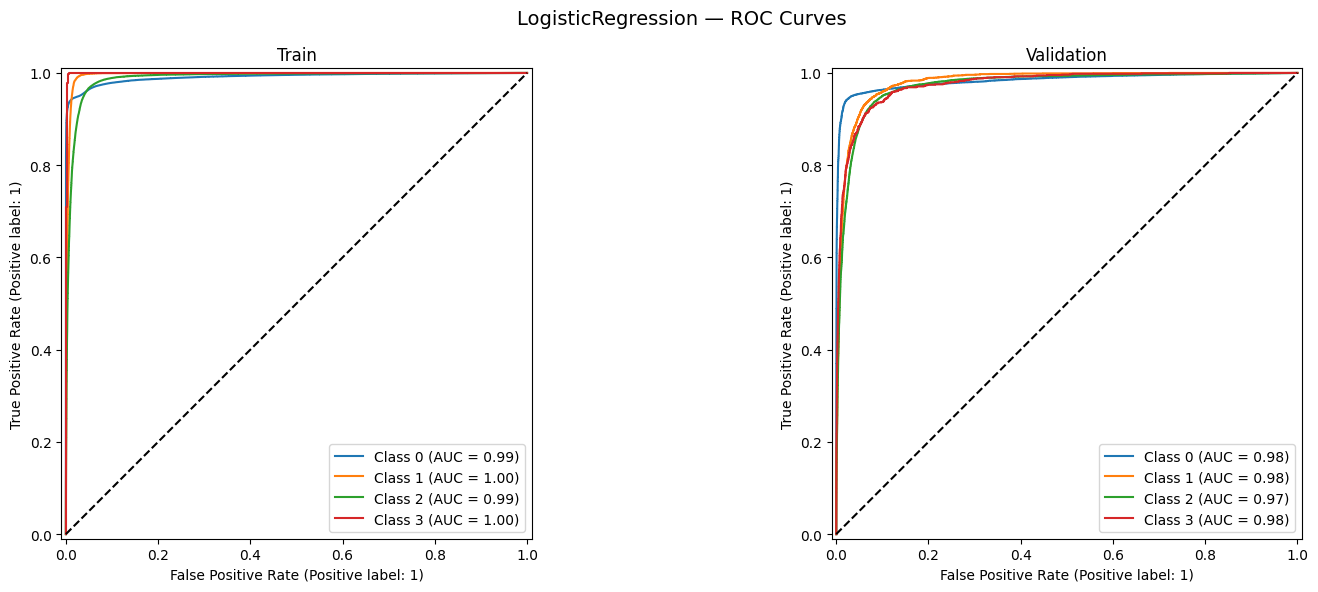


Training LinearSVC...


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[LinearSVC] No predict_proba — skipping threshold tuning and ROC curves

=== Results on train data ===
Accuracy      = 0.9275
F1 (macro)    = 0.8916
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     91338
           1       0.81      0.89      0.84     12735
           2       0.90      0.90      0.90     49952
           3       0.82      0.91      0.86      4375

    accuracy                           0.93    158400
   macro avg       0.87      0.91      0.89    158400
weighted avg       0.93      0.93      0.93    158400


=== Results on validation data ===
Accuracy      = 0.9100
F1 (macro)    = 0.8167
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     22835
           1       0.74      0.82      0.78      3183
           2       0.87      0.89      0.88     12488
           3       0.69      0.62      0.65      1094

    accuracy                           0.91     39600
   macro

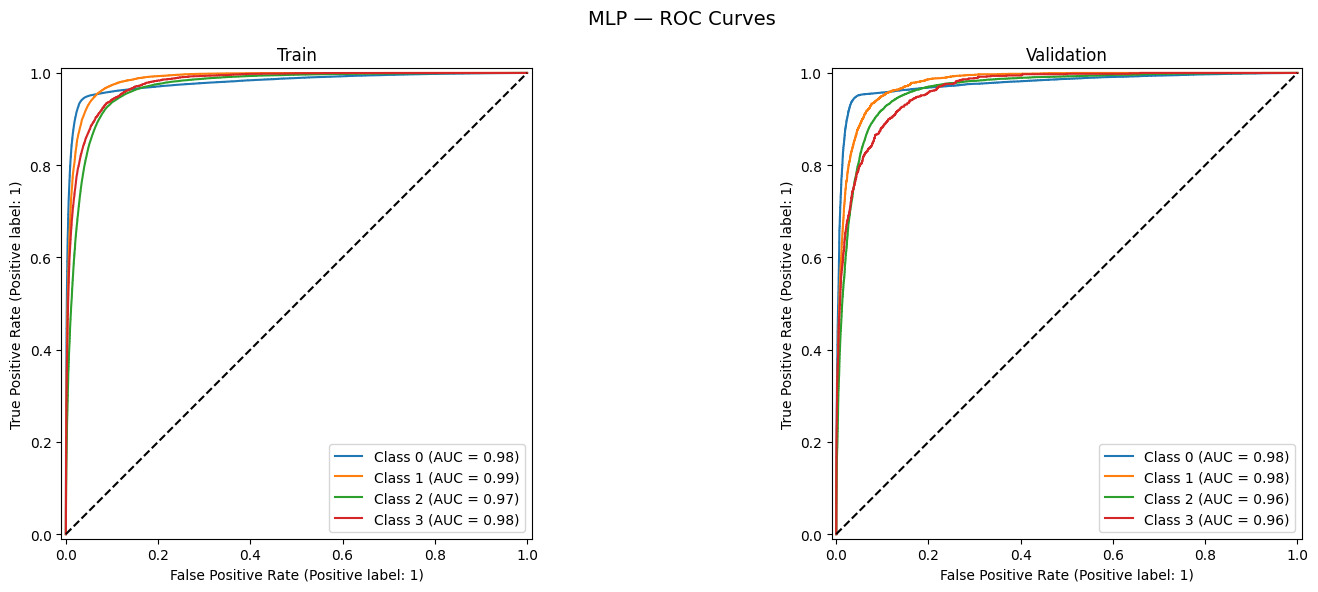


Training XGBoost...

=== Results on train data ===
Accuracy      = 0.8925
F1 (macro)    = 0.7290
ROC-AUC       = 0.9659
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     91338
           1       0.75      0.75      0.75     12735
           2       0.82      0.88      0.85     49952
           3       0.81      0.24      0.37      4375

    accuracy                           0.89    158400
   macro avg       0.83      0.70      0.73    158400
weighted avg       0.89      0.89      0.89    158400


=== Results on validation data ===
Accuracy      = 0.8873
F1 (macro)    = 0.7056
ROC-AUC       = 0.9539
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     22835
           1       0.71      0.72      0.71      3183
           2       0.81      0.87      0.84     12488
           3       0.76      0.20      0.31      1094

    accuracy                           0.89     39600
   macro avg 

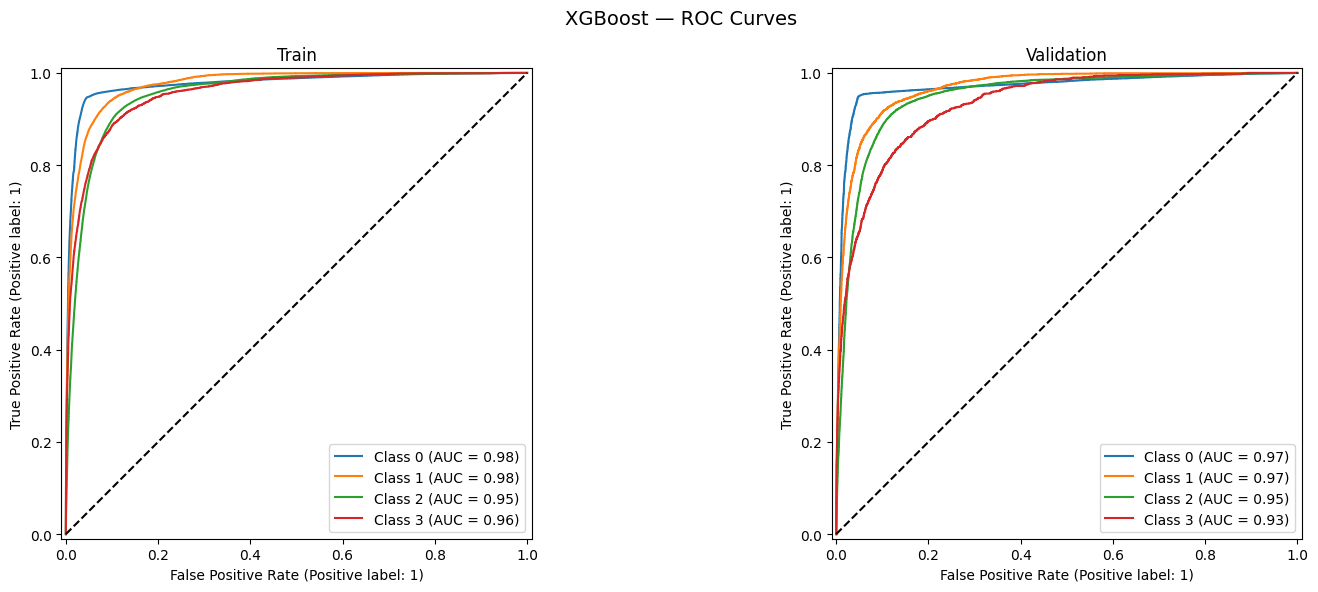

In [49]:
for name, pipe in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")

    pipe.fit(X_train_final, y_train)

    y_pred_train = pipe.predict(X_train_final)
    y_pred_val   = pipe.predict(X_val_final)

    try:
        proba_train = pipe.predict_proba(X_train_final)
        proba_val   = pipe.predict_proba(X_val_final)
        has_proba   = True
    except AttributeError:
        print(f"[{name}] No predict_proba — skipping threshold tuning and ROC curves")
        has_proba = False


    print('\n=== Results on train data ===')
    train_acc = accuracy_score(y_train, y_pred_train)
    train_f1  = f1_score(y_train, y_pred_train, average='macro')
    print(f"Accuracy      = {train_acc:.4f}")
    print(f"F1 (macro)    = {train_f1:.4f}")
    if has_proba:
        train_auc = roc_auc_score(y_train, proba_train, multi_class='ovr', average='macro')
        print(f"ROC-AUC       = {train_auc:.4f}")
    print(classification_report(y_train, y_pred_train))

    print('\n=== Results on validation data ===')
    val_acc = accuracy_score(y_val, y_pred_val)
    val_f1  = f1_score(y_val, y_pred_val, average='macro')
    print(f"Accuracy      = {val_acc:.4f}")
    print(f"F1 (macro)    = {val_f1:.4f}")
    if has_proba:
        val_auc = roc_auc_score(y_val, proba_val, multi_class='ovr', average='macro')
        print(f"ROC-AUC       = {val_auc:.4f}")
    print(classification_report(y_val, y_pred_val))
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred_val))


    if has_proba:
        classes     = np.unique(y_train)
        y_train_bin = label_binarize(y_train, classes=classes)
        y_val_bin   = label_binarize(y_val,   classes=classes)

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(f'{name} — ROC Curves', fontsize=14)

        for i, class_id in enumerate(classes):
            RocCurveDisplay.from_predictions(
                y_train_bin[:, i], proba_train[:, i],
                name=f"Class {class_id}", ax=axes[0]
            )
        axes[0].plot([0,1],[0,1],'k--')
        axes[0].set_title('Train')

        for i, class_id in enumerate(classes):
            RocCurveDisplay.from_predictions(
                y_val_bin[:, i], proba_val[:, i],
                name=f"Class {class_id}", ax=axes[1]
            )
        axes[1].plot([0,1],[0,1],'k--')
        axes[1].set_title('Validation')

        plt.tight_layout()
        plt.show()

    results[name] = {
        'pipe':      pipe,
        'train_f1':  train_f1,
        'val_f1':    val_f1,
        'has_proba': has_proba,
    }

In [50]:
print("\n" + "="*60)
print("FINAL MODEL COMPARISON")
print("="*60)

comparison = pd.DataFrame({
    name: {
        'Train F1':    f"{r['train_f1']:.4f}",
        'Val F1':      f"{r['val_f1']:.4f}",
        'Overfit Gap': f"{r['train_f1'] - r['val_f1']:.4f}",
    }
    for name, r in results.items()
}).T

print(comparison)


FINAL MODEL COMPARISON
                   Train F1  Val F1 Overfit Gap
LogisticRegression   0.9179  0.8189      0.0990
LinearSVC            0.8916  0.8167      0.0750
MLP                  0.8172  0.7889      0.0283
XGBoost              0.7290  0.7056      0.0234


In [51]:
best_name = max(results, key=lambda x: results[x]['val_f1'])
print(f"\nBest model: {best_name} (Val F1: {results[best_name]['val_f1']:.4f})")

best_pipe  = results[best_name]['pipe']
best_preds = best_pipe.predict(X_test_final)

submission = pd.DataFrame({
    "ID":    range(1, len(test_data) + 1),
    "label": best_preds
})
submission.to_csv("submission.csv", index=False)
print(f"Submission saved using {best_name}")


Best model: LogisticRegression (Val F1: 0.8189)
Submission saved using LogisticRegression


In [52]:
#print(search.best_params_)

#best_model = search.best_estimator_
#best_model.fit(X_train, y_train)

In [53]:
#y_pred_train = best_model.predict(X_train)
#y_pred_val = best_model.predict(X_val)

#y_pred_train = pipe.predict(X_train_final)
#y_pred_val = pipe.predict(X_val_final)

In [54]:
#proba_train = best_model.predict_proba(X_train)
#proba_val = best_model.predict_proba(X_val)

#proba_train = pipe.predict_proba(X_train_final)
#proba_val = pipe.predict_proba(X_val_final)

In [55]:
#def predict_with_thresholds(proba, thresholds):
#    adjusted = proba / np.array(thresholds)
#    return np.argmax(adjusted, axis=1)

In [56]:
'''
best_f1_full, best_t_full = 0, None

for t0 in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.4, 0.45]:
    for t1 in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.4, 0.45]:
        for t2 in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.4, 0.45]:
            for t3 in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.4, 0.45]:
                thresholds = [t0, t1, t2, t3]
                preds = predict_with_thresholds(proba_val, thresholds)
                f1 = f1_score(y_val, preds, average='macro')
                if f1 > best_f1_full:
                    best_f1_full = f1
                    best_t_full = thresholds

print(f"\nFull sweep best thresholds: {best_t_full}")
print(f"Full sweep best val F1:     {best_f1_full:.4f}")
'''

'\nbest_f1_full, best_t_full = 0, None\n\nfor t0 in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.4, 0.45]:\n    for t1 in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.4, 0.45]:\n        for t2 in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.4, 0.45]:\n            for t3 in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.4, 0.45]:\n                thresholds = [t0, t1, t2, t3]\n                preds = predict_with_thresholds(proba_val, thresholds)\n                f1 = f1_score(y_val, preds, average=\'macro\')\n                if f1 > best_f1_full:\n                    best_f1_full = f1\n                    best_t_full = thresholds\n\nprint(f"\nFull sweep best thresholds: {best_t_full}")\nprint(f"Full sweep best val F1:     {best_f1_full:.4f}")\n'

In [57]:
'''
best_preds = predict_with_thresholds(proba_val, best_t_full)
print("\n=== Val Results with Threshold Tuning ===")
print(classification_report(y_val, best_preds))

cm = confusion_matrix(y_val, best_preds)
print(cm)
f1 = f1_score(y_val, best_preds, average='macro')
print(f"F1 Score (macro) = {f1}\n")
'''

'\nbest_preds = predict_with_thresholds(proba_val, best_t_full)\nprint("\n=== Val Results with Threshold Tuning ===")\nprint(classification_report(y_val, best_preds))\n\ncm = confusion_matrix(y_val, best_preds)\nprint(cm)\nf1 = f1_score(y_val, best_preds, average=\'macro\')\nprint(f"F1 Score (macro) = {f1}\n")\n'

In [58]:
'''
print('=== Results on train data ===')
accuracy = accuracy_score(y_train, y_pred_train)
f1 = f1_score(y_train, y_pred_train, average='macro')
report = classification_report(y_train, y_pred_train)
auc_macro = roc_auc_score(y_train, proba_train, multi_class='ovr', average='macro')

print(f"Accuracy = {accuracy}\n")
print(f"ROC_AUC_score = {auc_macro}\n")
print(f"F1 Score (macro) = {f1}\n")
print("Classification report:\n")
print(report)
'''

'\nprint(\'=== Results on train data ===\')\naccuracy = accuracy_score(y_train, y_pred_train)\nf1 = f1_score(y_train, y_pred_train, average=\'macro\')\nreport = classification_report(y_train, y_pred_train)\nauc_macro = roc_auc_score(y_train, proba_train, multi_class=\'ovr\', average=\'macro\')\n\nprint(f"Accuracy = {accuracy}\n")\nprint(f"ROC_AUC_score = {auc_macro}\n")\nprint(f"F1 Score (macro) = {f1}\n")\nprint("Classification report:\n")\nprint(report)\n'

In [59]:
'''
print('=== Results on validation data ===')
accuracy = accuracy_score(y_val, y_pred_val)
report = classification_report(y_val, y_pred_val)
f1 = f1_score(y_val, y_pred_val, average='macro')
auc_macro = roc_auc_score(y_val, proba_val, multi_class='ovr', average='macro')

print(f"Accuracy = {accuracy}\n")
print(f"ROC_AUC_score = {auc_macro}\n")
print(f"F1 Score (macro) = {f1}\n")
print("Classification report:\n")
print(report)

cm = confusion_matrix(y_val, y_pred_val)
print(cm)
'''

'\nprint(\'=== Results on validation data ===\')\naccuracy = accuracy_score(y_val, y_pred_val)\nreport = classification_report(y_val, y_pred_val)\nf1 = f1_score(y_val, y_pred_val, average=\'macro\')\nauc_macro = roc_auc_score(y_val, proba_val, multi_class=\'ovr\', average=\'macro\')\n\nprint(f"Accuracy = {accuracy}\n")\nprint(f"ROC_AUC_score = {auc_macro}\n")\nprint(f"F1 Score (macro) = {f1}\n")\nprint("Classification report:\n")\nprint(report)\n\ncm = confusion_matrix(y_val, y_pred_val)\nprint(cm)\n'

In [60]:
'''from sklearn.preprocessing import label_binarize
from sklearn.metrics import RocCurveDisplay

classes = np.unique(y_train)
y_train_bin = label_binarize(y_train, classes=classes)

plt.figure(figsize=(8,6))

for i, class_id in enumerate(classes):
    RocCurveDisplay.from_predictions(
        y_train_bin[:, i],
        proba_train[:, i],
        name=f"Class {class_id}",
        ax=plt.gca())

plt.plot([0,1], [0,1], 'k--')
plt.title("Multiclass ROC Curves (Train)")
plt.show()
'''

'from sklearn.preprocessing import label_binarize\nfrom sklearn.metrics import RocCurveDisplay\n\nclasses = np.unique(y_train)\ny_train_bin = label_binarize(y_train, classes=classes)\n\nplt.figure(figsize=(8,6))\n\nfor i, class_id in enumerate(classes):\n    RocCurveDisplay.from_predictions(\n        y_train_bin[:, i],\n        proba_train[:, i],\n        name=f"Class {class_id}",\n        ax=plt.gca())\n\nplt.plot([0,1], [0,1], \'k--\')\nplt.title("Multiclass ROC Curves (Train)")\nplt.show()\n'

In [61]:
'''classes = np.unique(y_val)
y_val_bin = label_binarize(y_val, classes=classes)

plt.figure(figsize=(8,6))

for i, class_id in enumerate(classes):
    RocCurveDisplay.from_predictions(
        y_val_bin[:, i],
        proba_val[:, i],
        name=f"Class {class_id}",
        ax=plt.gca()
    )

plt.plot([0,1], [0,1], 'k--')
plt.title("Multiclass ROC Curves (Validation)")
plt.show()
'''

'classes = np.unique(y_val)\ny_val_bin = label_binarize(y_val, classes=classes)\n\nplt.figure(figsize=(8,6))\n\nfor i, class_id in enumerate(classes):\n    RocCurveDisplay.from_predictions(\n        y_val_bin[:, i],\n        proba_val[:, i],\n        name=f"Class {class_id}",\n        ax=plt.gca()\n    )\n\nplt.plot([0,1], [0,1], \'k--\')\nplt.title("Multiclass ROC Curves (Validation)")\nplt.show()\n'

In [62]:
'''test_proba = pipe.predict_proba(X_test)
test_preds = np.argmax(test_proba, axis=1)
confidence = test_proba.max(axis=1)

for t in [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
    n = (confidence > t).sum()
    print(f"Threshold {t:.2f} → {n} samples ({n/len(X_test)*100:.1f}%)")
    
plt.hist(confidence, bins=50)
plt.xlabel('Confidence')
plt.ylabel('Count')
plt.title('Test Prediction Confidence Distribution')
plt.axvline(x=0.90, color='r', linestyle='--', label='threshold=0.90')
plt.legend()
plt.show()
'''

'test_proba = pipe.predict_proba(X_test)\ntest_preds = np.argmax(test_proba, axis=1)\nconfidence = test_proba.max(axis=1)\n\nfor t in [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:\n    n = (confidence > t).sum()\n    print(f"Threshold {t:.2f} → {n} samples ({n/len(X_test)*100:.1f}%)")\n    \nplt.hist(confidence, bins=50)\nplt.xlabel(\'Confidence\')\nplt.ylabel(\'Count\')\nplt.title(\'Test Prediction Confidence Distribution\')\nplt.axvline(x=0.90, color=\'r\', linestyle=\'--\', label=\'threshold=0.90\')\nplt.legend()\nplt.show()\n'

In [63]:
'''
feature_names = pipe['prep'].get_feature_names_out()

coef = pipe['model'].coef_

classes = pipe['model'].classes_ 

for i, cls in enumerate(classes):
    class_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': coef[i]
    }).sort_values('coefficient', ascending=False)

    print(f"\n=== CLASS {cls} — TOP 20 ===")
    print(class_df.head(20).to_string(index=False))

    print(f"\n=== CLASS {cls} — BOTTOM 40 ===")
    print(class_df.tail(40).to_string(index=False))
'''

'\nfeature_names = pipe[\'prep\'].get_feature_names_out()\n\ncoef = pipe[\'model\'].coef_\n\nclasses = pipe[\'model\'].classes_ \n\nfor i, cls in enumerate(classes):\n    class_df = pd.DataFrame({\n        \'feature\': feature_names,\n        \'coefficient\': coef[i]\n    }).sort_values(\'coefficient\', ascending=False)\n\n    print(f"\n=== CLASS {cls} — TOP 20 ===")\n    print(class_df.head(20).to_string(index=False))\n\n    print(f"\n=== CLASS {cls} — BOTTOM 40 ===")\n    print(class_df.tail(40).to_string(index=False))\n'

In [64]:
'''#predictions = best_model.predict(X_test)
predictions = pipe.predict(X_test)

submission = pd.DataFrame({
    "ID": range(1, len(test_data) + 1),
    "label": predictions
})

submission.to_csv("submission.csv", index=False)
'''

'#predictions = best_model.predict(X_test)\npredictions = pipe.predict(X_test)\n\nsubmission = pd.DataFrame({\n    "ID": range(1, len(test_data) + 1),\n    "label": predictions\n})\n\nsubmission.to_csv("submission.csv", index=False)\n'

In [65]:
'''mlp = best_model.named_steps['model']

print("Layers:", mlp.n_layers_)
print("Output classes:", mlp.classes_)
print("Outputs:", mlp.n_outputs_)
print("Hidden layer sizes:", mlp.hidden_layer_sizes)

print("Epochs trained:", mlp.n_iter_)
print("Loss:", mlp.loss_)
print("Best validation score:", mlp.best_validation_score_ )

print("Activation:", mlp.activation)
print("Solver:", mlp.solver)

layer_sizes = [mlp.coefs_[0].shape[0]] + [w.shape[1] for w in mlp.coefs_]
print("Neurons per layer:", layer_sizes)'''

'mlp = best_model.named_steps[\'model\']\n\nprint("Layers:", mlp.n_layers_)\nprint("Output classes:", mlp.classes_)\nprint("Outputs:", mlp.n_outputs_)\nprint("Hidden layer sizes:", mlp.hidden_layer_sizes)\n\nprint("Epochs trained:", mlp.n_iter_)\nprint("Loss:", mlp.loss_)\nprint("Best validation score:", mlp.best_validation_score_ )\n\nprint("Activation:", mlp.activation)\nprint("Solver:", mlp.solver)\n\nlayer_sizes = [mlp.coefs_[0].shape[0]] + [w.shape[1] for w in mlp.coefs_]\nprint("Neurons per layer:", layer_sizes)'

# Milestones Code


In [66]:
'''print("==== MILESTONE 4 ====")

train_data = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test_data = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

train_data.fillna({'comment':""}, inplace = True)
print(train_data['comment'].isnull().sum())

X = train_data.drop('label', axis = 1)
y = train_data['label']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.4, 
                                                    random_state = 2306, stratify=y)

train_counts = y_train.value_counts().sort_index().to_numpy()
val_counts = y_val.value_counts().sort_index().to_numpy()

X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(X, y, test_size = 0.4, 
                                                    random_state = 2306, stratify = None)

train_counts_b = y_train_b.value_counts().sort_index().to_numpy()
val_counts_b = y_val_b.value_counts().sort_index().to_numpy()

train_norm = train_counts/ train_counts.sum()
val_norm = val_counts/ val_counts.sum()
train_norm_b = train_counts_b/ train_counts_b.sum()
val_norm_b = val_counts_b/ val_counts_b.sum()

print(train_norm, train_norm_b)
print(val_norm, val_norm_b)

train_diff = abs(train_norm - train_norm_b)
val_diff = abs(val_norm - val_norm_b)

print(train_diff, val_diff)

print(f"Max diff: {max(train_diff.max(), val_diff.max())}")

X_train.columns

text_x_train = X_train["comment"]
text_x_val = X_val["comment"]

X_train.drop(columns=['created_date', 'comment'], inplace = True)
X_val.drop(columns=['created_date', 'comment'], inplace = True)

cat_cols = ["race", "religion", "gender", "disability"]

num_cols = [
    "post_id", "emoticon_1", "emoticon_2", "emoticon_3",
    "upvote", "downvote", "if_1", "if_2"
]

from sklearn.impute import SimpleImputer

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

tabular_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_pipeline, cat_cols),
        ("num", num_pipeline, num_cols)
    ],
    remainder="passthrough"
)

tabular_preprocessor.fit(X_train)
x_train_tabular = tabular_preprocessor.transform(X_train)
x_val_tabular = tabular_preprocessor.transform(X_val)

def normalize_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', '  ', text).strip()
    return text

text_x_train_norm = text_x_train.apply(normalize_text)
text_x_val_norm = text_x_val.apply(normalize_text)

tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
tfidf.fit(text_x_train_norm)

tf_idf_train = tfidf.transform(text_x_train_norm)
tf_idf_val = tfidf.transform(text_x_val_norm)

from scipy.sparse import hstack

X_train_final = hstack([x_train_tabular, tf_idf_train])
X_val_final = hstack([x_val_tabular, tf_idf_val])

print(round(X_train_final.sum(), 3))

from sklearn.decomposition import TruncatedSVD

trunc_svd = TruncatedSVD(n_components=300, random_state=2306)
trunc_svd.fit(X_train_final)

X_train_reduced = trunc_svd.transform(X_train_final)
X_val_reduced = trunc_svd.transform(X_val_final)

rf = RandomForestClassifier(random_state=2306)
param_dict = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 15]}

randomized_search = RandomizedSearchCV(rf,param_distributions=param_dict,
                                       n_iter=5,cv=3,random_state=2306,n_jobs=-1)

randomized_search.fit(X_train_reduced, y_train)

print(randomized_search.best_params_)

from sklearn.ensemble import AdaBoostClassifier

adb_clf = AdaBoostClassifier(n_estimators=50, random_state=2306)

adb_clf.fit(X_train_reduced, y_train)

print(adb_clf.estimator_errors_)
print(round(np.var(adb_clf.estimator_errors_), 4))

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=2306)
rf_clf.fit(X_train_reduced, y_train)

feature_importances = rf_clf.feature_importances_
max_index = feature_importances.argmax()


print(max_index)

mlp = MLPClassifier(hidden_layer_sizes=(128, 64, 32),activation="relu",
    random_state=2306)

mlp.fit(X_train_reduced, y_train)

total_weights = sum(w.size for w in mlp.coefs_)
print(total_weights)

mlp_2 = MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation = 'relu',
                      solver = "adam", max_iter = 5, batch_size = 32, random_state = 2306)

mlp_2.fit(X_train_reduced, y_train)

print(round(mlp_2.loss_, 4))

from sklearn.metrics import f1_score

mlp_a = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=5,
    alpha=0.0001,
    random_state=2306
)


mlp_b = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=5,
    alpha=1.0,
    random_state=2306
)


mlp_a.fit(X_train_reduced, y_train)
mlp_b.fit(X_train_reduced, y_train)

y_pred_a = mlp_a.predict(X_train_reduced)
y_pred_b = mlp_b.predict(X_train_reduced)

f1_a = f1_score(y_train, y_pred_a, average="macro")
f1_b = f1_score(y_train, y_pred_b, average="macro")

diff = abs(f1_a - f1_b)

print("Model A Macro F1:", f1_a)
print("Model B Macro F1:", f1_b)
print("Absolute Difference:", round(diff, 4))

from sklearn.metrics import confusion_matrix

y_val_pred = mlp_2.predict(X_val_reduced)
cm = confusion_matrix(y_val, y_val_pred)

misclassified = cm.sum() - np.trace(cm)

total_samples = cm.sum()

result = misclassified / total_samples
print(round(result, 4))'''

<>:78: SyntaxWarning: invalid escape sequence '\S'
<>:78: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_17/1091492720.py:78: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub(r'http\S+|www\S+', '', text)


'print("==== MILESTONE 4 ====")\n\ntrain_data = pd.read_csv(\'/kaggle/input/comment-category-prediction-challenge/train.csv\')\ntest_data = pd.read_csv(\'/kaggle/input/comment-category-prediction-challenge/test.csv\')\n\ntrain_data.fillna({\'comment\':""}, inplace = True)\nprint(train_data[\'comment\'].isnull().sum())\n\nX = train_data.drop(\'label\', axis = 1)\ny = train_data[\'label\']\nX_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.4, \n                                                    random_state = 2306, stratify=y)\n\ntrain_counts = y_train.value_counts().sort_index().to_numpy()\nval_counts = y_val.value_counts().sort_index().to_numpy()\n\nX_train_b, X_val_b, y_train_b, y_val_b = train_test_split(X, y, test_size = 0.4, \n                                                    random_state = 2306, stratify = None)\n\ntrain_counts_b = y_train_b.value_counts().sort_index().to_numpy()\nval_counts_b = y_val_b.value_counts().sort_index().to_numpy()\n\ntrain_norm = 

In [67]:
'''print('==== MILESTONE 5 ====')

df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
y = df['label']
df.drop('label', axis = 1, inplace = True)

df['created_date'] = pd.to_datetime(df['created_date'])
test_df['created_date'] = pd.to_datetime(test_df['created_date'])

print(df['created_date'].dtype)
print(test_df['created_date'].dtype)

df['year'] = df['created_date'].dt.year
df['month'] = df['created_date'].dt.month
df['hour'] = df['created_date'].dt.hour

test_df['year'] = test_df['created_date'].dt.year
test_df['month'] = test_df['created_date'].dt.month
test_df['hour'] = test_df['created_date'].dt.hour

df.drop('created_date', axis = 1, inplace = True)
test_df.drop('created_date', axis = 1, inplace = True)

print(df.columns)
print('\n\n', test_df.columns)

df.fillna({'race': 'Unknown', 'religion': 'Unknown', 'gender': 'Unknown', 'comment':""}, inplace=True)
test_df.fillna({'race': 'Unknown', 'religion': 'Unknown', 'gender': 'Unknown', 'comment':""}, inplace=True)

df['disability'] = df['disability'].astype(int)
test_df['disability'] = test_df['disability'].astype(int)

preprocessor = ColumnTransformer(
    transformers=
    [
        ('text', TfidfVectorizer(stop_words="english", max_features=5000), 'comment'),
        ('cat', OneHotEncoder(drop="first", handle_unknown="ignore"), ['race', 'religion', 'gender'] )
    ],
    remainder = "passthrough"
)

X = preprocessor.fit_transform(df)
X_test = preprocessor.transform(test_df)

X_train, X_val, y_train, y_val = train_test_split(X, y, random_state = 42, test_size = 0.2)

text_features = preprocessor.named_transformers_['text'].get_feature_names_out()
print(f"Number of text features: {len(text_features)}")

print(X_train.shape[1], X_val.shape[1])

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

mnb_clf = MultinomialNB()
mnb_clf.fit(X_train, y_train)
y_pred = mnb_clf.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {round(accuracy, 3)}")


from sklearn.metrics import classification_report

report = classification_report(y_val, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print(report_df)

precision_label_3 = report['3']['precision']
print(f"Precision for label 3: {precision_label_3:.4f}")

from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(max_iter = 500, random_state = 42)
lr_clf.fit(X_train, y_train)
y_pred = lr_clf.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {round(accuracy, 3)}")


y_pred_train = lr_clf.predict(X_train)
accuracy_train = accuracy_score(y_train, y_pred_train)
print(f"Accuracy: {round(accuracy, 2)}")


report = classification_report(y_val, y_pred, output_dict=True)

print(report)
precision_label_1 = report['1']['precision']

print(round(precision_label_1, 2))

param_dict = {
    'C':[0.1, 1, 10],
    'solver':['liblinear']
}

search = GridSearchCV(
    lr_clf,
    param_dict,
    cv = 3,
    n_jobs=-1,
    scoring = 'accuracy'
)

search.fit(X_train, y_train)

print(search.best_params_)

y_cv_pred = search.predict(X_val)
accuarcy = accuracy_score(y_val, y_cv_pred)
print(f"Accuracy = {round(accuracy,2)}")'''

'print(\'==== MILESTONE 5 ====\')\n\ndf = pd.read_csv(\'/kaggle/input/comment-category-prediction-challenge/train.csv\')\ntest_df = pd.read_csv(\'/kaggle/input/comment-category-prediction-challenge/test.csv\')\ny = df[\'label\']\ndf.drop(\'label\', axis = 1, inplace = True)\n\ndf[\'created_date\'] = pd.to_datetime(df[\'created_date\'])\ntest_df[\'created_date\'] = pd.to_datetime(test_df[\'created_date\'])\n\nprint(df[\'created_date\'].dtype)\nprint(test_df[\'created_date\'].dtype)\n\ndf[\'year\'] = df[\'created_date\'].dt.year\ndf[\'month\'] = df[\'created_date\'].dt.month\ndf[\'hour\'] = df[\'created_date\'].dt.hour\n\ntest_df[\'year\'] = test_df[\'created_date\'].dt.year\ntest_df[\'month\'] = test_df[\'created_date\'].dt.month\ntest_df[\'hour\'] = test_df[\'created_date\'].dt.hour\n\ndf.drop(\'created_date\', axis = 1, inplace = True)\ntest_df.drop(\'created_date\', axis = 1, inplace = True)\n\nprint(df.columns)\nprint(\'\n\n\', test_df.columns)\n\ndf.fillna({\'race\': \'Unknown\', \

# Additional Extra Code

**NOTE! The below code was used in some versions of the notebook, not used now**

In [68]:
'''threat_verbs = ['kill', 'shoot', 'bomb', 'hang', 'burn', 'stab', 
                'execute', 'murder', 'beat', 'knife', 'die', 'death']

threat_patterns = [
    r'\b(kill|shoot|murder|execute)\s+(you|him|her|them|all)\b',
    r'\b(hope|wish|want).{0,20}(dies?|killed|shot|dead)\b',
    r'\b(should|must|needs? to)\s+be\s+(killed|shot|hanged|executed)\b',
    r'\bdeserves?\s+(to\s+die|death|bullet|prison|jail)\b',
    r'\b(lock|throw).{0,10}(away|jail|prison)\b',
    r'\bdeath\s+penalty\b',
    r'\bfiring\s+squad\b',
]

def extract_threat_features(text):
    text_lower = text.lower()
    features = {}
    features['threat_verb_count'] = sum(1 for v in threat_verbs if v in text_lower)
    features['has_threat_pattern'] = int(any(re.search(p, text_lower) for p in threat_patterns))
    features['has_hope_death'] = int(bool(re.search(r'\bhope.{0,30}(die|dead|kill)', text_lower)))
    features['has_deserves'] = int('deserves' in text_lower and 
                                    any(v in text_lower for v in threat_verbs))
    return features

from sklearn.preprocessing import FunctionTransformer

def threat_feature_matrix(texts):
    rows = [extract_threat_features(t) for t in texts]
    return pd.DataFrame(rows).values

threat_vocab = [
    'kill', 'shoot', 'bomb', 'execute', 'murder', 'hang', 'burn',
    'death penalty', 'firing squad', 'bullet', 'knife', 'gun', 'shot',
    'deserves to die', 'lock up', 'throw away', 'prison', 'jail',
    'hope you die', 'should be killed', 'death', 'dead', 'killing'
]

threat_tfidf = TfidfVectorizer(vocabulary=threat_vocab, ngram_range=(1,3))'''

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_17/503976433.py:5: SyntaxWarning: invalid escape sequence '\s'
  r'\b(kill|shoot|murder|execute)\s+(you|him|her|them|all)\b',


"threat_verbs = ['kill', 'shoot', 'bomb', 'hang', 'burn', 'stab', \n                'execute', 'murder', 'beat', 'knife', 'die', 'death']\n\nthreat_patterns = [\n    r'\x08(kill|shoot|murder|execute)\\s+(you|him|her|them|all)\x08',\n    r'\x08(hope|wish|want).{0,20}(dies?|killed|shot|dead)\x08',\n    r'\x08(should|must|needs? to)\\s+be\\s+(killed|shot|hanged|executed)\x08',\n    r'\x08deserves?\\s+(to\\s+die|death|bullet|prison|jail)\x08',\n    r'\x08(lock|throw).{0,10}(away|jail|prison)\x08',\n    r'\x08death\\s+penalty\x08',\n    r'\x08firing\\s+squad\x08',\n]\n\ndef extract_threat_features(text):\n    text_lower = text.lower()\n    features = {}\n    features['threat_verb_count'] = sum(1 for v in threat_verbs if v in text_lower)\n    features['has_threat_pattern'] = int(any(re.search(p, text_lower) for p in threat_patterns))\n    features['has_hope_death'] = int(bool(re.search(r'\x08hope.{0,30}(die|dead|kill)', text_lower)))\n    features['has_deserves'] = int('deserves' in text_low

-------------- Tracking Best Params --------------
1. LR
{'prep__tfidf__word__ngram_range': (1, 2), 'prep__tfidf__word__min_df': 2, 'prep__tfidf__word__max_features': 20000, 'prep__tfidf__word__max_df': 0.85, 'prep__tfidf__char__ngram_range': (3, 5), 'prep__tfidf__char__min_df': 2, 'prep__tfidf__char__max_features': 20000, 'prep__tfidf__char__max_df': 0.9, 'model__max_iter': 500, 'model__class_weight': None, 'model__C': 0.1}

2. MLP
{'model__hidden_layer_sizes': (3,), 'prep__tfidf__char__max_df': 0.9, 'prep__tfidf__char__max_features': 20000, 'prep__tfidf__char__min_df': 2, 'prep__tfidf__char__ngram_range': (3, 4), 'prep__tfidf__word__max_df': 0.85, 'prep__tfidf__word__max_features': 20000, 'prep__tfidf__word__min_df': 2, 'prep__tfidf__word__ngram_range': (1, 2)}

3. LIGHTGBM
prep__text__tfidf__ngram_range': (1, 4), 'prep__text__tfidf__min_df': 2, 'prep__text__tfidf__max_features': 5000, 'prep__text__svd__n_components': 200, 'model__subsample': 1.0, 'model__reg_lambda': 0, 'model__reg_alpha': 0.1, 'model__num_leaves': 127, 'model__n_estimators': 200, 'model__min_gain_to_split': 0.0, 'model__min_child_weight': 0.1, 'model__min_child_samples': 10, 'model__max_depth': 10, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.6

4. XGB
prep__text__tfidf__ngram_range': (1, 3), 'prep__text__tfidf__min_df': 2, 'prep__text__tfidf__max_features': 5000, 'prep__text__svd__n_components': 200, 'model__subsample': 0.9, 'model__reg_lambda': 5, 'model__reg_alpha': 1, 'model__n_estimators': 300, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__gamma': 0.1, 'model__colsample_bytree': 1.0}


In [69]:
'''train_with_labels = X_train.copy()
train_with_labels['label'] = y_train
post_stats = train_with_labels.groupby('post_id')['label'].agg(
    post_mean_label='mean',
    post_class1_rate=lambda x: (x==1).mean(),
    post_class3_rate=lambda x: (x==3).mean(),
    post_toxicity_rate=lambda x: (x>0).mean(),
    post_comment_count='count'
)

X_train = X_train.merge(post_stats, on='post_id', how='left')
X_val   = X_val.merge(post_stats, on='post_id', how='left')
X_test  = test_data.merge(post_stats, on='post_id', how='left')'''

"train_with_labels = X_train.copy()\ntrain_with_labels['label'] = y_train\npost_stats = train_with_labels.groupby('post_id')['label'].agg(\n    post_mean_label='mean',\n    post_class1_rate=lambda x: (x==1).mean(),\n    post_class3_rate=lambda x: (x==3).mean(),\n    post_toxicity_rate=lambda x: (x>0).mean(),\n    post_comment_count='count'\n)\n\nX_train = X_train.merge(post_stats, on='post_id', how='left')\nX_val   = X_val.merge(post_stats, on='post_id', how='left')\nX_test  = test_data.merge(post_stats, on='post_id', how='left')"

In [70]:
'''global_stats = {
    'post_mean_label':    y_train.mean(),
    'post_class1_rate':   (y_train == 1).mean(),
    'post_class3_rate':   (y_train == 3).mean(),
    'post_toxicity_rate': (y_train > 0).mean(),
    'post_comment_count': X_train.groupby('post_id').size().mean()
}

post_stat_cols = list(global_stats.keys())
X_val[post_stat_cols]  = X_val[post_stat_cols].fillna(global_stats)
X_test[post_stat_cols] = X_test[post_stat_cols].fillna(global_stats)'''

"global_stats = {\n    'post_mean_label':    y_train.mean(),\n    'post_class1_rate':   (y_train == 1).mean(),\n    'post_class3_rate':   (y_train == 3).mean(),\n    'post_toxicity_rate': (y_train > 0).mean(),\n    'post_comment_count': X_train.groupby('post_id').size().mean()\n}\n\npost_stat_cols = list(global_stats.keys())\nX_val[post_stat_cols]  = X_val[post_stat_cols].fillna(global_stats)\nX_test[post_stat_cols] = X_test[post_stat_cols].fillna(global_stats)"

In [71]:
'''voting = VotingClassifier(
    estimators=[('lr', lr),  ('svc', svc)],
    voting='soft',
    weights=[1, 1],
    n_jobs=-1
)

pipe = Pipeline([
    ('prep', preprocessor),
    ('model', voting)
], memory="cache")

pipe.fit(X_train, y_train)'''

'voting = VotingClassifier(\n    estimators=[(\'lr\', lr),  (\'svc\', svc)],\n    voting=\'soft\',\n    weights=[1, 1],\n    n_jobs=-1\n)\n\npipe = Pipeline([\n    (\'prep\', preprocessor),\n    (\'model\', voting)\n], memory="cache")\n\npipe.fit(X_train, y_train)'

In [72]:
'''pipe = Pipeline([
    ('prep', preprocessor),
    ('model', LGBMClassifier(
    objective='multiclass',
    num_class=4,
    random_state=42,
    n_jobs=-1,
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=50,
    reg_lambda=2.0,
    reg_alpha=0.5,
    colsample_bytree=0.6,
    subsample=0.8,
    subsample_freq=5,
    class_weight={0:1, 1:3, 2:2, 3:8},
    force_col_wise=True
))
], memory="cache")'''

'pipe = Pipeline([\n    (\'prep\', preprocessor),\n    (\'model\', LGBMClassifier(\n    objective=\'multiclass\',\n    num_class=4,\n    random_state=42,\n    n_jobs=-1,\n    n_estimators=300,\n    learning_rate=0.05,\n    num_leaves=31,\n    min_child_samples=50,\n    reg_lambda=2.0,\n    reg_alpha=0.5,\n    colsample_bytree=0.6,\n    subsample=0.8,\n    subsample_freq=5,\n    class_weight={0:1, 1:3, 2:2, 3:8},\n    force_col_wise=True\n))\n], memory="cache")'